Creating the pipeline and the model. Training the model

In [303]:
import numpy as np
from src.ai_lib import layers
from src.ai_lib import Sequential, Model
from src.ai_lib import losses
from src.ai_lib import optimizers
from src.ai_lib import metrics

def load_local_mnist(images_path):
    with open(images_path, 'rb') as f:
        data = np.frombuffer(f.read(), np.uint8, offset=16)
    
    X = data.reshape(-1, 1, 28, 28) / 255.0
    
    return X.astype(np.float32)

X_train = load_local_mnist('data/mnist/train-images.idx3-ubyte')
X_val = load_local_mnist('data/mnist/t10k-images.idx3-ubyte')

vae = Sequential([
                  # Encoder
                  layers.Conv2d(1, out_channels=16, kernel_size=3, stride=2, padding=1), # Output: (B, 16, 14, 14)
                  layers.ReLU(),
                  layers.Conv2d(16, 32, kernel_size=3, stride=2, padding=1), # Output: (B, 32, 7, 7)
                  layers.ReLU(),

                  layers.Flatten(),
                  layers.Linear(32 * 7 * 7, 4),

                  # Latent space 
                  layers.SamplingLayer(kl_weight = 0.5),

                  # Decoder
                  layers.Linear(2, 16 * 7 * 7),
                  layers.ReLU(),
                  layers.Reshape((16, 7, 7)),

                  layers.ConvTranspose2d(16, 8, kernel_size=4, stride=2, padding=1), # Output: (B, 8, 14, 14)
                  layers.ReLU(),
                  layers.ConvTranspose2d(8, 1, kernel_size=4, stride=2, padding=1), # Output: (B, 1, 28, 28)
                  layers.Sigmoid()
                  ])

model = Model(vae)
model.fit(X_train, X_train, 20, losses.BinaryCrossEntropy(), optimizers.Adam(learning_rate=0.001, weight_decay=0.01), batch_size=16, accumulation_steps=4, validation_data=[X_val, X_val], early_stopping=True, patience=4)



Iteration 0 completed, loss is 202.60114683701013
Iteration 0 completed, validation loss is 168.9917237245094
Iteration 1 completed, loss is 166.3811782752754
Iteration 1 completed, validation loss is 163.542325215145
Iteration 2 completed, loss is 162.17030557847778
Iteration 2 completed, validation loss is 160.05080805479236
Iteration 3 completed, loss is 159.3831415225275
Iteration 3 completed, validation loss is 157.85171438558191
Iteration 4 completed, loss is 157.56391475782786
Iteration 4 completed, validation loss is 156.1368123068035
Iteration 5 completed, loss is 156.34630885786572
Iteration 5 completed, validation loss is 155.71148845200148
Iteration 6 completed, loss is 155.50348282656964
Iteration 6 completed, validation loss is 155.11391379498528
Iteration 7 completed, loss is 154.92821761461653
Iteration 7 completed, validation loss is 154.048432936582
Iteration 8 completed, loss is 154.40404508200453
Iteration 8 completed, validation loss is 154.04274404220595
Iteration

Génération d'images

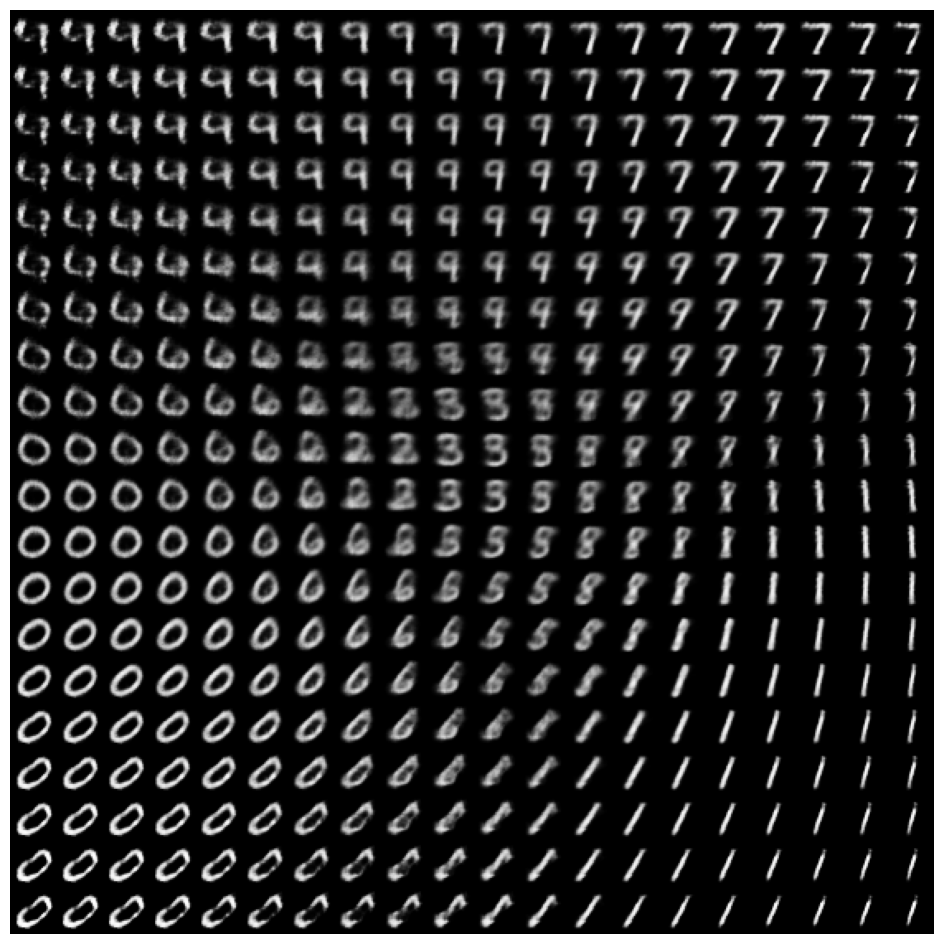

In [349]:
import matplotlib.pyplot as plt

decoder_layers = vae.layers[-7:]

decoder = Sequential(decoder_layers)
decoder.set_training(False)

n = 20  # n^2 is the number of images
digit_size = 28

figure = np.zeros((digit_size * n, digit_size * n))

grid_x = np.linspace(-3, 3, n)
grid_y = np.linspace(-3, 3, n)[::-1] 

for i, yi in enumerate(grid_y):
    for j, xi in enumerate(grid_x):
        z_sample = np.array([[xi, yi]], dtype=np.float32)

        x_decoded = decoder.forward(z_sample)
        
        # Removing the batch dimension
        digit = x_decoded[0].reshape(digit_size, digit_size)
        
        figure[i * digit_size: (i + 1) * digit_size,
               j * digit_size: (j + 1) * digit_size] = digit


# Plotting
plt.figure(figsize=(12, 12))
plt.imshow(figure, cmap='gray')
plt.axis('off')
plt.show()